In [19]:
import pandas as pd
import numpy as np

In [20]:
car_fuel = pd.read_csv('/home/ron/projects/ml-zoomcamp-homework/1.homework/car_fuel_efficiency.csv')
car_fuel.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


The goal of this homework is to create a regression model for predicting the car fuel efficiency (column 'fuel_efficiency_mpg').

Preparing the dataset
Use only the following columns:

'engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg'


Axes(0.125,0.11;0.775x0.77)


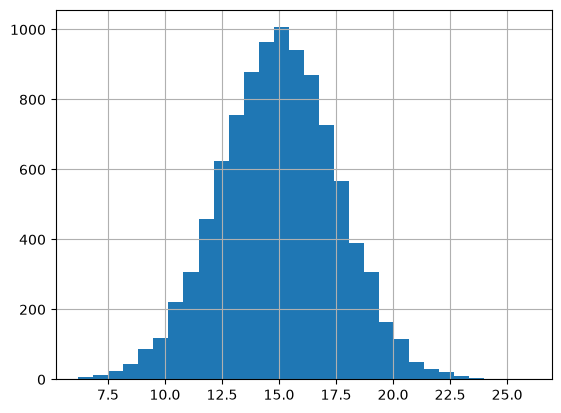

In [21]:
#EDA
car_fuel['fuel_efficiency_mpg'].describe()
print(car_fuel['fuel_efficiency_mpg'].hist(bins=30))

In [22]:
features = ['engine_displacement', 'horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']

In [23]:
#Question 1
#There's one column with missing values. What is it?
car_fuel[features].isna().sum()



engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [24]:
#Question 2
#What's the median (50% percentile) for variable 'horsepower'?

car_fuel[features].describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,9704.000000,8996.000000,9704.000000,9704.000000,9704.000000
mean,199.708368,149.657292,3001.280993,2011.484027,14.985243
std,49.455319,29.879555,497.894860,6.659808,2.556468
min,10.000000,37.000000,952.681761,2000.000000,6.200971
25%,170.000000,130.000000,2666.248985,2006.000000,13.267459
50%,200.000000,149.000000,2993.226296,2012.000000,15.006037
75%,230.000000,170.000000,3334.957039,2017.000000,16.707965
max,380.000000,271.000000,4739.077089,2023.000000,25.967222


In [25]:
#Prepare and split the dataset
#Shuffle the dataset (the filtered one you created above), use seed 42.
#Split your data in train/val/test sets, with 60%/20%/20% distribution.
car_fuel = car_fuel[features].copy()
print(car_fuel.head())

# shuffle with fixed seed
car_fuel = car_fuel.sample(frac=1, random_state=42).reset_index(drop=True)

n_total = len(car_fuel)
n_train = int(0.6 * n_total)
n_val = int(0.2 * n_total)
n_test = n_total - n_train - n_val

train_df = car_fuel.iloc[:n_train].copy()
val_df = car_fuel.iloc[n_train:n_train + n_val].copy()
test_df = car_fuel.iloc[n_train + n_val:].copy()

print(len(train_df), len(val_df), len(test_df))

   engine_displacement  horsepower  vehicle_weight  model_year  \
0                  170       159.0     3413.433759        2003   
1                  130        97.0     3149.664934        2007   
2                  170        78.0     3079.038997        2018   
3                  220         NaN     2542.392402        2009   
4                  210       140.0     3460.870990        2009   

   fuel_efficiency_mpg  
0            13.231729  
1            13.688217  
2            14.246341  
3            16.912736  
4            12.488369  
5822 1940 1942


In [26]:
"""Question 3
We need to deal with missing values for the column from Q1.
We have two options: fill it with 0 or with the mean of this variable.
Try both options. For each, train a linear regression model without regularization using the code from the lessons.
For computing the mean, use the training only!
Use the validation dataset to evaluate the models and compare the RMSE of each option.
Round the RMSE scores to 2 decimal digits using round(score, 2)
Which option gives better RMSE?
Options:

With 0
With mean
Both are equally good"""


from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# example feature set
features = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year'
]

# target
target = 'fuel_efficiency_mpg'

# assume df is already filtered and split
# df_train, df_val are already created

# Option 1: fill with 0
df_train_0 = train_df.copy()
df_val_0 = val_df.copy()

df_train_0['horsepower'] = df_train_0['horsepower'].fillna(0)
df_val_0['horsepower'] = df_val_0['horsepower'].fillna(0)

X_train_0 = df_train_0[features]
y_train_0 = df_train_0[target]
X_val_0 = df_val_0[features]
y_val_0 = df_val_0[target]

model_0 = LinearRegression()
model_0.fit(X_train_0, y_train_0)
pred_0 = model_0.predict(X_val_0)
rmse_0 = np.sqrt(mean_squared_error(y_val_0, pred_0))

# Option 2: fill with mean from training only
mean_hp = train_df['horsepower'].mean()

df_train_mean = train_df.copy()
df_val_mean = val_df.copy()

df_train_mean['horsepower'] = df_train_mean['horsepower'].fillna(mean_hp)
df_val_mean['horsepower'] = df_val_mean['horsepower'].fillna(mean_hp)

X_train_mean = df_train_mean[features]
y_train_mean = df_train_mean[target]
X_val_mean = df_val_mean[features]
y_val_mean = df_val_mean[target]

model_mean = LinearRegression()
model_mean.fit(X_train_mean, y_train_mean)
pred_mean = model_mean.predict(X_val_mean)
rmse_mean = np.sqrt(mean_squared_error(y_val_mean, pred_mean))

print(round(rmse_0, 2))
print(round(rmse_mean, 2))

0.52
0.46


In [27]:
"""Question 4
Now let's train a regularized linear regression.
For this question, fill the NAs with 0.
Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
Use RMSE to evaluate the model on the validation dataset.
Round the RMSE scores to 2 decimal digits.
Which r gives the best RMSE?
If multiple options give the same best RMSE, select the smallest r.
"""

from sklearn.linear_model import Ridge

# Fill missing horsepower values with 0 in both datasets.
df_train_ridge = train_df.copy()
df_val_ridge = val_df.copy()
df_train_ridge['horsepower'] = df_train_ridge['horsepower'].fillna(0)
df_val_ridge['horsepower'] = df_val_ridge['horsepower'].fillna(0)

X_train_ridge = df_train_ridge[features]
y_train_ridge = df_train_ridge[target]
X_val_ridge = df_val_ridge[features]
y_val_ridge = df_val_ridge[target]

# Fit and evaluate one model for each regularization strength.
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
rmse_scores = {}

for r in r_values:
    model_ridge = Ridge(alpha=r)
    model_ridge.fit(X_train_ridge, y_train_ridge)
    predictions = model_ridge.predict(X_val_ridge)
    rmse_scores[r] = np.sqrt(mean_squared_error(y_val_ridge, predictions))

# Compare rounded scores; min() selects the smallest r when scores tie.
rounded_rmse_scores = {r: round(score, 2) for r, score in rmse_scores.items()}
for r, score in rounded_rmse_scores.items():
    print(f'r={r}: RMSE={score}')

best_r = min(r_values, key=lambda r: (rounded_rmse_scores[r], r))
print(f'Best r: {best_r} (RMSE={rounded_rmse_scores[best_r]})')

r=0: RMSE=0.52
r=0.01: RMSE=0.52
r=0.1: RMSE=0.52
r=1: RMSE=0.52
r=5: RMSE=0.52
r=10: RMSE=0.52
r=100: RMSE=0.52
Best r: 0 (RMSE=0.52)


In [28]:
"""Question 5
We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
For each seed, do the train/validation/test split with 60%/20%/20% distribution.
Fill the missing values with 0 and train a model without regularization.
For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
Round the result to 3 decimal digits (round(std, 3))
What's the value of std?"""

seed_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_scores_by_seed = []

for seed in seed_values:
    shuffled_df = car_fuel.sample(frac=1, random_state=seed).reset_index(drop=True)

    n_total = len(shuffled_df)
    n_train = int(0.6 * n_total)
    n_val = int(0.2 * n_total)

    train_seed_df = shuffled_df.iloc[:n_train].copy()
    val_seed_df = shuffled_df.iloc[n_train:n_train + n_val].copy()
    test_seed_df = shuffled_df.iloc[n_train + n_val:].copy()

    train_seed_df['horsepower'] = train_seed_df['horsepower'].fillna(0)
    val_seed_df['horsepower'] = val_seed_df['horsepower'].fillna(0)

    X_train_seed = train_seed_df[features]
    y_train_seed = train_seed_df[target]
    X_val_seed = val_seed_df[features]
    y_val_seed = val_seed_df[target]

    model_seed = LinearRegression()
    model_seed.fit(X_train_seed, y_train_seed)
    predictions_seed = model_seed.predict(X_val_seed)
    rmse_seed = np.sqrt(mean_squared_error(y_val_seed, predictions_seed))
    rmse_scores_by_seed.append(rmse_seed)

std = np.std(rmse_scores_by_seed)
print('RMSE scores:', [round(score, 3) for score in rmse_scores_by_seed])
print('Standard deviation:', round(std, 3))

RMSE scores: [np.float64(0.516), np.float64(0.509), np.float64(0.516), np.float64(0.527), np.float64(0.533), np.float64(0.518), np.float64(0.513), np.float64(0.53), np.float64(0.507), np.float64(0.521)]
Standard deviation: 0.008


In [29]:
"""Question 6
Split the dataset like previously, use seed 9.
Combine train and validation datasets.
Fill the missing values with 0 and train a model with r=0.001.
What's the RMSE on the test dataset?
"""

from sklearn.linear_model import Ridge

# Shuffle and split the data with seed 9.
shuffled_df = car_fuel.sample(frac=1, random_state=9).reset_index(drop=True)
n_total = len(shuffled_df)
n_train = int(0.6 * n_total)
n_val = int(0.2 * n_total)

train_seed9_df = shuffled_df.iloc[:n_train].copy()
val_seed9_df = shuffled_df.iloc[n_train:n_train + n_val].copy()
test_seed9_df = shuffled_df.iloc[n_train + n_val:].copy()

# Train on the combined training and validation datasets.
train_val_seed9_df = pd.concat([train_seed9_df, val_seed9_df])
train_val_seed9_df['horsepower'] = train_val_seed9_df['horsepower'].fillna(0)
test_seed9_df['horsepower'] = test_seed9_df['horsepower'].fillna(0)

X_train_val_seed9 = train_val_seed9_df[features]
y_train_val_seed9 = train_val_seed9_df[target]
X_test_seed9 = test_seed9_df[features]
y_test_seed9 = test_seed9_df[target]

model_seed9 = Ridge(alpha=0.001)
model_seed9.fit(X_train_val_seed9, y_train_val_seed9)
predictions_test_seed9 = model_seed9.predict(X_test_seed9)
rmse_test_seed9 = np.sqrt(mean_squared_error(y_test_seed9, predictions_test_seed9))
print('Test RMSE:', rmse_test_seed9)

Test RMSE: 0.5286242013551838


# Homework 2 Notebook Guide

This notebook builds regression models to predict `fuel_efficiency_mpg` from car characteristics. It explores the data, compares ways of handling missing horsepower values, checks regularization and split-seed effects, and evaluates a final model on a held-out test set.

## Cell-by-cell walkthrough

### Cell 1: Import libraries
Imports pandas for dataframes and NumPy for numerical calculations such as square roots and standard deviations.

### Cell 2: Load the dataset
Reads the car fuel-efficiency CSV into `car_fuel` and displays the first few rows so the data and column names can be inspected.

### Cell 3: State the objective and selected columns
Introduces the regression target and lists the columns intended for the analysis: engine displacement, horsepower, vehicle weight, model year, and fuel efficiency.

### Cell 4: Explore the target distribution
Requests descriptive statistics for `fuel_efficiency_mpg` and plots a 30-bin histogram. Since the `describe()` expression is followed by a `print()` call, the statistics may not appear as a separate notebook output; the histogram is the displayed output.

### Cell 5: Define the initial column list
Creates `features`, listing the selected dataset columns, including the target. The data-preparation cell uses this list to filter the dataframe. Later, Question 3 resets `features` to contain predictors only, while `target` separately names `fuel_efficiency_mpg`.

### Cell 6: Question 1, find missing values
Counts nulls for each selected column. This identifies `horsepower` as the column with missing values.

### Cell 7: Question 2, summarize horsepower
Displays descriptive statistics for the selected columns. The `50%` row gives the median horsepower requested by the question.

### Cell 8: Prepare and split the dataset
Keeps only the selected columns, shuffles the rows with seed `42`, and divides them into training, validation, and test sets. The split proportions are 60%, 20%, and 20%; the resulting dataframes are `train_df`, `val_df`, and `test_df`.

### Cell 9: Question 3, compare missing-value strategies
Defines the predictor columns and target, then fits two unregularized `LinearRegression` models. The first replaces missing horsepower with `0`; the second replaces it with the mean horsepower computed from the training set only. Both models are evaluated on validation RMSE. In the executed results, the scores round to `0.52` for zero-fill and `0.46` for mean-fill, so mean-fill performs better.

### Cell 10: Question 4, compare Ridge regularization strengths
Replaces missing horsepower with `0` in the training and validation data, then fits a `Ridge` model for each requested `r` (`alpha`) value. It calculates validation RMSE, rounds the displayed scores to two decimals, and selects the smallest `r` if rounded scores tie. In the executed output, all candidates round to `0.52`, so the smallest value, `r = 0`, is selected.

### Cell 11: Question 5, measure split-seed variability
Repeats the 60/20/20 shuffle and split for seeds `0` through `9`. For each seed it zero-fills missing horsepower, trains an unregularized linear regression on the training subset, and calculates validation RMSE. It uses `np.std` to calculate the spread of the ten scores; the result rounds to `0.008`.

### Cell 12: Question 6, final test evaluation
Shuffles and splits the data using seed `9`, combines the training and validation subsets, fills missing horsepower with `0`, and fits `Ridge(alpha=0.001)`. It evaluates only once on the held-out test subset. The executed test RMSE is approximately `0.5286`.

## Workflow summary
The validation set is used to compare modeling choices in Questions 3–5. Question 6 combines training and validation data for the final fit, then reports performance on the test set, which was held aside for that final evaluation.